In [2]:
## Module 1: Introduction to Linear Regression

### Concept Overview
Linear regression models the relationship between a dependent variable (y) and one or more independent variables (x) using a linear equation: y = Î²â‚€ + Î²â‚xâ‚ + Î²â‚‚xâ‚‚ + ... + Î²â‚™xâ‚™ + Îµ

**Key Concepts:**
- Dependent variable (target): The value we want to predict
- Independent variables (features): Variables used for prediction
- Coefficients (Î²): Weights showing feature importance
- Intercept (Î²â‚€): Base value when all features are zero
- Error (Îµ): Difference between predicted and actual values

---

### Task 1.1: Understanding the Data

**Scenario:** You're working at a real estate company. Your manager wants to predict house prices based on their size.

**Dataset Description:**
- `size_sqft`: House size in square feet
- `price`: House price in thousands of dollars

**Your Task:**
1. Load the following sample data into a pandas DataFrame
2. Explore the data using `.head()`, `.info()`, and `.describe()`
3. Create a scatter plot to visualize the relationship between size and price

**Sample Data (copy this):**
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample data
data = {
    'size_sqft': [650, 785, 920, 1050, 1180, 1320, 1450, 1580, 1720, 1850,
                  2000, 2150, 2300, 2450, 2600, 2750, 2900, 3050, 3200, 3350],
    'price': [85, 95, 110, 125, 135, 150, 165, 175, 190, 200,
              215, 225, 240, 255, 270, 285, 295, 310, 325, 340]
}
df = pd.DataFrame(data)
```

**Questions to Answer:**
1. How many houses are in the dataset?
2. What is the average house size and average price?
3. Based on the scatter plot, does there appear to be a linear relationship?

**Python Code Template:**
```python
# TODO: Import necessary libraries

# TODO: Create the DataFrame

# TODO: Explore the data
print("Dataset Overview:")
# Your code here

# TODO: Calculate basic statistics
print("\nBasic Statistics:")
# Your code here

# TODO: Create scatter plot
# Your code here
plt.xlabel('House Size (sqft)')
plt.ylabel('Price ($1000s)')
plt.title('House Size vs Price')
plt.show()
```

**Why This Matters:**
Understanding your data is the first step in any machine learning project. Data exploration helps you identify patterns, outliers, and the nature of relationships between variables.

---

### Task 1.2: Building Your First Linear Regression Model

**Your Task:**
1. Split the data into training (80%) and testing (20%) sets
2. Build a simple linear regression model using scikit-learn
3. Train the model on the training data
4. Make predictions on the test data
5. Visualize the regression line along with the data points

**Python Code Template:**
```python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# TODO: Prepare features (X) and target (y)
X = # Your code here
y = # Your code here

# TODO: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    # Your code here
)

# TODO: Create and train the model
model = # Your code here
# Your code here

# TODO: Make predictions
y_pred = # Your code here

# TODO: Visualize the results
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('House Size (sqft)')
plt.ylabel('Price ($1000s)')
plt.title('Linear Regression: House Price Prediction')
plt.legend()
plt.show()
```

**Questions to Answer:**
1. What is the equation of your regression line? (y = Î²â‚€ + Î²â‚x)
2. If a house is 2500 sqft, what price does your model predict?
3. What does the slope coefficient tell you about the relationship between size and price?

**Why This Matters:**
Building a simple model first helps you understand the basics before tackling complex problems. This foundational skill is essential for all future regression tasks.

---

### Task 1.3: Model Evaluation

**Your Task:**
1. Calculate Mean Squared Error (MSE)
2. Calculate Root Mean Squared Error (RMSE)
3. Calculate RÂ² Score (coefficient of determination)
4. Interpret what these metrics tell you about model performance

**Python Code Template:**
```python
# TODO: Calculate evaluation metrics
mse = # Your code here
rmse = # Your code here
r2 = # Your code here

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"RÂ² Score: {r2:.4f}")

# TODO: Create a residual plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()
```

**Questions to Answer:**
1. What does an RÂ² score of 0.95 mean in practical terms?
2. What do the residuals in your plot tell you about model performance?
3. Is your model underfitting, overfitting, or well-fitted? Why?

**Why This Matters:**
Model evaluation is critical for understanding whether your predictions are reliable. In business, poor model evaluation can lead to costly decisions based on inaccurate predictions.

---

## Module 2: Multiple Linear Regression

###  Concept Overview
Multiple linear regression extends simple linear regression by using multiple features to predict the target variable. This better represents real-world scenarios where outcomes depend on multiple factors.

---

### Task 2.1: Multivariate Analysis

**Scenario:** The real estate company now wants to predict house prices using multiple features: size, number of bedrooms, age of the house, and distance from city center.

**Your Task:**
1. Load and explore the expanded dataset
2. Create a correlation matrix to understand feature relationships
3. Visualize correlations using a heatmap

**Sample Data:**
```python
import seaborn as sns

# Expanded dataset
data_multi = {
    'size_sqft': [650, 785, 920, 1050, 1180, 1320, 1450, 1580, 1720, 1850,
                  2000, 2150, 2300, 2450, 2600, 2750, 2900, 3050, 3200, 3350,
                  1100, 1250, 1400, 1650, 1900, 2200, 2500, 2800, 3100, 3400],
    'bedrooms': [1, 1, 2, 2, 2, 3, 3, 3, 3, 4,
                 4, 4, 4, 5, 5, 5, 5, 6, 6, 6,
                 2, 2, 3, 3, 3, 4, 4, 5, 5, 6],
    'age_years': [45, 38, 35, 30, 28, 25, 20, 18, 15, 12,
                  10, 8, 5, 3, 2, 1, 1, 0, 0, 0,
                  32, 28, 25, 22, 18, 15, 12, 8, 5, 2],
    'distance_miles': [15, 14, 13, 12, 11, 10, 9, 8, 7, 6,
                       5, 5, 4, 3, 3, 2, 2, 1, 1, 1,
                       12, 11, 10, 9, 8, 7, 6, 5, 4, 3],
    'price': [85, 95, 110, 125, 135, 150, 165, 175, 190, 200,
              215, 225, 240, 255, 270, 285, 295, 310, 325, 340,
              128, 138, 155, 172, 188, 210, 230, 260, 285, 315]
}
df_multi = pd.DataFrame(data_multi)
```

**Python Code Template:**
```python
# TODO: Explore the dataset
print(df_multi.head())
print(df_multi.describe())

# TODO: Create correlation matrix
correlation_matrix = # Your code here

# TODO: Visualize with heatmap
plt.figure(figsize=(10, 8))
# Your code here (use seaborn heatmap)
plt.title('Feature Correlation Heatmap')
plt.show()
```

**Questions to Answer:**
1. Which feature has the strongest correlation with price?
2. Are any features highly correlated with each other? (multicollinearity concern)
3. Which feature has a negative correlation with price? Why might this be?

**Why This Matters:**
In real-world scenarios, outcomes are rarely determined by a single factor. Understanding how multiple variables interact helps build more accurate and useful models. Identifying correlations also helps detect multicollinearity issues.

---

### Task 2.2: Building Multiple Linear Regression Model

**Your Task:**
1. Build a multiple linear regression model using all features
2. Compare its performance to the simple linear regression model
3. Analyze the coefficients to understand feature importance
4. Make predictions for new houses

**Python Code Template:**
```python
# TODO: Prepare features and target
X_multi = # Your code here (select all feature columns)
y_multi = # Your code here

# TODO: Split the data
X_train_m, X_test_m, y_train_m, y_test_m = # Your code here

# TODO: Create and train the model
model_multi = # Your code here
# Your code here

# TODO: Make predictions and evaluate
y_pred_multi = # Your code here

# TODO: Calculate metrics
mse_multi = # Your code here
rmse_multi = # Your code here
r2_multi = # Your code here

print(f"Multiple Regression RÂ² Score: {r2_multi:.4f}")

# TODO: Display coefficients
coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': model_multi.coef_
})
print("\nFeature Coefficients:")
print(coefficients.sort_values('Coefficient', ascending=False))
```

**Questions to Answer:**
1. How does the RÂ² score compare to the simple linear regression model?
2. Which feature has the largest coefficient? What does this mean?
3. Why might age have a negative coefficient?
4. Predict the price of a house with: 2200 sqft, 3 bedrooms, 10 years old, 5 miles from city

**Why This Matters:**
Multiple regression captures complex real-world relationships. Understanding feature coefficients helps stakeholders make informed decisions (e.g., "Adding a bedroom increases value by $X").

---

### Task 2.3: Feature Selection and Model Refinement

**Your Task:**
1. Use feature importance to identify the most influential variables
2. Build a reduced model using only the top 2-3 features
3. Compare the reduced model performance with the full model
4. Discuss the trade-offs between model complexity and performance

**Python Code Template:**
```python
# TODO: Visualize feature importance
plt.figure(figsize=(10, 6))
# Create bar chart of absolute coefficient values
# Your code here

# TODO: Build reduced model with top features
top_features = # Your code here (select top 2-3 features)
X_reduced = # Your code here
X_train_r, X_test_r, y_train_r, y_test_r = # Your code here

model_reduced = # Your code here
# Train and evaluate

# TODO: Compare all three models
comparison = pd.DataFrame({
    'Model': ['Simple LR', 'Multiple LR', 'Reduced LR'],
    'Features': [1, 4, len(top_features)],
    'RÂ² Score': [# Fill with your results],
    'RMSE': [# Fill with your results]
})
print(comparison)
```

**Questions to Answer:**
1. How much performance do you lose by using fewer features?
2. In what scenarios might you prefer the reduced model over the full model?
3. What is the principle of Occam's Razor and how does it apply here?

**Why This Matters:**
Simpler models are easier to interpret, maintain, and deploy. In business, a slightly less accurate model that stakeholders can understand may be more valuable than a black-box model with marginally better performance.

---

##  Module 3: Polynomial Regression

###  Concept Overview
Polynomial regression handles non-linear relationships by transforming features into polynomial terms. For example: y = Î²â‚€ + Î²â‚x + Î²â‚‚xÂ² + Î²â‚ƒxÂ³

**When to Use:**
- When scatter plots show curved patterns
- When simple linear regression has poor fit
- When domain knowledge suggests non-linear relationships

---

###  Task 3.1: Identifying Non-Linear Patterns

**Scenario:** You're analyzing the relationship between a car's age and its resale value. The depreciation is not linearâ€”newer cars depreciate faster.

**Sample Data:**
```python
# Car depreciation data
car_data = {
    'age_years': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'value_percentage': [100, 80, 65, 55, 48, 42, 38, 35, 32, 30, 28, 26, 24, 22, 21, 20]
}
df_car = pd.DataFrame(car_data)
```

**Your Task:**
1. Create a scatter plot of age vs value
2. Fit a simple linear regression model
3. Visualize the linear fit and observe the poor performance
4. Calculate the RÂ² score

**Python Code Template:**
```python
# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
# Your code here

# TODO: Fit linear regression
X_car = # Your code here
y_car = # Your code here

model_linear_car = # Your code here
# Train model

y_pred_linear = # Your code here
r2_linear_car = # Your code here

# TODO: Plot linear fit
plt.scatter(X_car, y_car, label='Actual Data')
plt.plot(X_car, y_pred_linear, color='red', label='Linear Fit')
plt.xlabel('Car Age (years)')
plt.ylabel('Value (% of original)')
plt.title('Car Depreciation - Linear Model')
plt.legend()
plt.show()

print(f"Linear Model RÂ²: {r2_linear_car:.4f}")
```

**Questions to Answer:**
1. Does the linear model capture the depreciation pattern well?
2. Where does the model perform worst? (early years, middle, or late years?)
3. What shape does the actual relationship appear to have?

**Why This Matters:**
Many real-world relationships are non-linear. Forcing linear models on curved data leads to poor predictions, especially at the extremes. Recognizing when to use non-linear models is a critical skill.

---

###  Task 3.2: Implementing Polynomial Regression

**Your Task:**
1. Transform features using PolynomialFeatures
2. Build polynomial regression models of degree 2, 3, and 4
3. Compare their performance with the linear model
4. Visualize all models on the same plot

**Python Code Template:**
```python
from sklearn.preprocessing import PolynomialFeatures

# TODO: Create polynomial features and models for degrees 2, 3, 4
degrees = [2, 3, 4]
models = {}
predictions = {}
r2_scores = {}

for degree in degrees:
    # TODO: Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = # Your code here

    # TODO: Train model
    model = LinearRegression()
    # Your code here

    # TODO: Make predictions and calculate RÂ²
    y_pred = # Your code here
    r2 = # Your code here

    models[degree] = model
    predictions[degree] = y_pred
    r2_scores[degree] = r2

# TODO: Visualize all models
plt.figure(figsize=(12, 8))
plt.scatter(X_car, y_car, label='Actual Data', s=50)
plt.plot(X_car, y_pred_linear, label='Linear', linestyle='--')

for degree in degrees:
    plt.plot(X_car, predictions[degree], label=f'Degree {degree}')

plt.xlabel('Car Age (years)')
plt.ylabel('Value (% of original)')
plt.title('Polynomial Regression Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# TODO: Print comparison
print("\nModel Performance Comparison:")
print(f"Linear Model RÂ²: {r2_linear_car:.4f}")
for degree in degrees:
    print(f"Polynomial (degree {degree}) RÂ²: {r2_scores[degree]:.4f}")
```

**Questions to Answer:**
1. Which polynomial degree provides the best fit for this data?
2. Is there evidence of overfitting with higher degrees?
3. At what car age (0-15 years) does each model make the most different predictions?
4. Which model would you recommend for business use? Why?

**Why This Matters:**
Polynomial regression balances the need for capturing non-linear patterns while avoiding overfitting. Choosing the right degree is crucial too low and you underfit, too high and you overfit.

---

###  Task 3.3: Cross-Validation for Model Selection

**Your Task:**
1. Implement k-fold cross-validation for different polynomial degrees
2. Use cross-validation scores to select the optimal degree
3. Understand the bias-variance tradeoff

**Python Code Template:**
```python
from sklearn.model_selection import cross_val_score

# TODO: Test degrees 1 through 8
degrees_to_test = range(1, 9)
cv_scores_mean = []
cv_scores_std = []

for degree in degrees_to_test:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_car)

    # TODO: Perform 5-fold cross-validation
    scores = cross_val_score(
        # Your code here
        # Use negative MSE as scoring metric
    )

    cv_scores_mean.append(-scores.mean())  # Convert back to positive MSE
    cv_scores_std.append(scores.std())

# TODO: Visualize cross-validation scores
plt.figure(figsize=(10, 6))
plt.plot(degrees_to_test, cv_scores_mean, marker='o')
plt.fill_between(degrees_to_test,
                 np.array(cv_scores_mean) - np.array(cv_scores_std),
                 np.array(cv_scores_mean) + np.array(cv_scores_std),
                 alpha=0.2)
plt.xlabel('Polynomial Degree')
plt.ylabel('Cross-Validation MSE')
plt.title('Model Selection via Cross-Validation')
plt.grid(True)
plt.show()

# TODO: Find optimal degree
optimal_degree = # Your code here
print(f"\nOptimal polynomial degree: {optimal_degree}")
```

**Questions to Answer:**
1. What happens to CV scores as degree increases beyond the optimal point?
2. Why is cross-validation better than a single train-test split?
3. What does increasing standard deviation tell you about model stability?
4. Explain the bias-variance tradeoff in the context of your results

**Why This Matters:**
Cross-validation provides robust model selection by testing on multiple data splits. This is crucial in production environments where model reliability matters more than peak performance on a single test set.

---

##  Module 4: Regularization Techniques

###  Concept Overview
Regularization prevents overfitting by adding a penalty term to the loss function. This constrains the model coefficients, creating simpler, more generalizable models.

**Types of Regularization:**
- **Ridge Regression (L2):** Penalizes sum of squared coefficients; shrinks all coefficients
- **Lasso Regression (L1):** Penalizes sum of absolute coefficients; can zero out coefficients
- **Elastic Net:** Combines L1 and L2 penalties

---

###  Task 4.1: Understanding the Overfitting Problem

**Scenario:** You're building a model to predict student exam scores based on study hours, but you have many potentially correlated features.

**Sample Data:**
```python
# Student performance data with many features
np.random.seed(42)
n_samples = 50

student_data = {
    'study_hours': np.random.uniform(0, 10, n_samples),
    'previous_score': np.random.uniform(40, 100, n_samples),
    'attendance_pct': np.random.uniform(50, 100, n_samples),
    'homework_completion': np.random.uniform(30, 100, n_samples),
    'class_participation': np.random.uniform(20, 100, n_samples),
    'sleep_hours': np.random.uniform(4, 9, n_samples),
    'exercise_hours': np.random.uniform(0, 5, n_samples),
    'social_media_hours': np.random.uniform(0, 8, n_samples),
}

# Create target with realistic relationship + noise
df_student = pd.DataFrame(student_data)
df_student['exam_score'] = (
    20 +
    3 * df_student['study_hours'] +
    0.4 * df_student['previous_score'] +
    0.2 * df_student['attendance_pct'] +
    np.random.normal(0, 8, n_samples)
)
```

**Your Task:**
1. Build a standard linear regression model with all features
2. Evaluate training and testing performance separately
3. Identify signs of overfitting

**Python Code Template:**
```python
from sklearn.preprocessing import StandardScaler

# TODO: Prepare data
X_student = df_student.drop('exam_score', axis=1)
y_student = df_student['exam_score']

# TODO: Split data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_student, y_student, test_size=0.3, random_state=42
)

# TODO: Standardize features (important for regularization!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_s)
X_test_scaled = scaler.transform(X_test_s)

# TODO: Train standard linear regression
model_standard = LinearRegression()
# Your code here

# TODO: Evaluate on both train and test sets
train_r2 = # Your code here
test_r2 = # Your code here
train_rmse = # Your code here
test_rmse = # Your code here

print("Standard Linear Regression:")
print(f"Training RÂ²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
print(f"Testing RÂ²: {test_r2:.4f}, RMSE: {test_rmse:.2f}")
print(f"Overfit Gap (Train RÂ² - Test RÂ²): {train_r2 - test_r2:.4f}")
```

**Questions to Answer:**
1. Is there a significant gap between training and testing performance?
2. What does this gap indicate about your model?
3. Why is feature scaling important for regularization methods?

**Why This Matters:**
Overfitting is one of the most common problems in machine learning. A model that performs well on training data but poorly on new data is useless in production. Learning to detect and prevent overfitting is essential.

---

### Task 4.2: Ridge Regression Implementation

**Your Task:**
1. Implement Ridge regression with different alpha values
2. Use RidgeCV to find the optimal alpha
3. Compare Ridge performance with standard linear regression
4. Analyze how regularization affects coefficients

**Python Code Template:**
```python
from sklearn.linear_model import Ridge, RidgeCV

# TODO: Test different alpha values
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for alpha in alphas:
    # TODO: Train Ridge model
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train_s)

    # TODO: Evaluate
    train_r2 = ridge.score(X_train_scaled, y_train_s)
    test_r2 = ridge.score(X_test_scaled, y_test_s)

    ridge_results.append({
        'alpha': alpha,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'gap': train_r2 - test_r2
    })

# TODO: Create results DataFrame and visualize
results_df = pd.DataFrame(ridge_results)
print(results_df)

# TODO: Plot performance vs alpha
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.semilogx(results_df['alpha'], results_df['train_r2'], label='Train RÂ²', marker='o')
plt.semilogx(results_df['alpha'], results_df['test_r2'], label='Test RÂ²', marker='s')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('RÂ² Score')
plt.title('Ridge Regression: Performance vs Alpha')
plt.legend()
plt.grid(True)

# TODO: Use RidgeCV to find optimal alpha automatically
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train_s)

print(f"\nOptimal Alpha (via Cross-Validation): {ridge_cv.alpha_}")

# TODO: Compare coefficient magnitudes
plt.subplot(1, 2, 2)
# Compare coefficients between standard LR and Ridge
# Your code here

plt.tight_layout()
plt.show()
```

**Questions to Answer:**
1. What happens to the train-test gap as alpha increases?
2. What is the optimal alpha value and why?
3. How do Ridge coefficients compare to standard linear regression coefficients?
4. Can you identify which features Ridge considers less important?

**Why This Matters:**
Ridge regression is widely used in industry when you have many correlated features. It provides more stable predictions than standard regression and reduces the risk of overfitting while keeping all features in the model.

---

###  Task 4.3: Lasso Regression for Feature Selection

**Your Task:**
1. Implement Lasso regression
2. Observe how Lasso performs automatic feature selection
3. Compare Lasso with Ridge regression
4. Identify which features Lasso considers most important

**Python Code Template:**
```python
from sklearn.linear_model import Lasso, LassoCV

# TODO: Test different alpha values for Lasso
alphas_lasso = [0.001, 0.01, 0.1, 1, 5, 10]
lasso_results = []
lasso_coefficients = []

for alpha in alphas_lasso:
    # TODO: Train Lasso model
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_s)

    # TODO: Count non-zero coefficients
    non_zero_coefs = np.sum(lasso.coef_ != 0)

    # TODO: Evaluate
    train_r2 = lasso.score(X_train_scaled, y_train_s)
    test_r2 = lasso.score(X_test_scaled, y_test_s)

    lasso_results.append({
        'alpha': alpha,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'non_zero_features': non_zero_coefs
    })
    lasso_coefficients.append(lasso.coef_)

# TODO: Visualize results
lasso_df = pd.DataFrame(lasso_results)
print("Lasso Results:")
print(lasso_df)

# TODO: Use LassoCV for optimal alpha
lasso_cv = LassoCV(alphas=alphas_lasso, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train_s)

print(f"\nOptimal Alpha for Lasso: {lasso_cv.alpha_:.4f}")

# TODO: Visualize feature selection
plt.figure(figsize=(12, 6))
# Create coefficient paths plot showing how coefficients change with alpha
# Your code here

# TODO: Display final selected features
final_lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
final_lasso.fit(X_train_scaled, y_train_s)

feature_importance = pd.DataFrame({
    'Feature': X_student.columns,
    'Coefficient': final_lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nFeature Importance (Lasso):")
print(feature_importance)
```

**Questions to Answer:**
1. How many features does Lasso zero out at the optimal alpha?
2. Which features does Lasso consider most important? Does this match your intuition?
3. What are the advantages of Lasso over Ridge for this problem?
4. When would you prefer Lasso over Ridge in practice?

**Why This Matters:**
Lasso is powerful for feature selection, especially when you have many features and suspect only a few are truly important. This creates more interpretable models and can reduce data collection costs in production.

---

###  Task 4.4: Elastic Net - Best of Both Worlds

**Your Task:**
1. Implement Elastic Net regression
2. Tune both the L1 ratio and alpha parameters
3. Compare Elastic Net with Ridge and Lasso
4. Make recommendations for which method to use in different scenarios

**Python Code Template:**
```python
from sklearn.linear_model import ElasticNet, ElasticNetCV

# TODO: Test different combinations of alpha and l1_ratio
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
alphas_en = [0.001, 0.01, 0.1, 1, 10]

best_score = -np.inf
best_params = {}

for l1_ratio in l1_ratios:
    for alpha in alphas_en:
        # TODO: Train Elastic Net
        elastic = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        elastic.fit(X_train_scaled, y_train_s)

        # TODO: Evaluate on test set
        test_score = elastic.score(X_test_scaled, y_test_s)

        if test_score > best_score:
            best_score = test_score
            best_params = {'alpha': alpha, 'l1_ratio': l1_ratio}

print(f"Best Parameters: {best_params}")
print(f"Best Test RÂ²: {best_score:.4f}")

# TODO: Use ElasticNetCV for automatic tuning
elastic_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas_en,
    cv=5,
    max_iter=10000
)
elastic_cv.fit(X_train_scaled, y_train_s)

# TODO: Create comprehensive comparison
comparison_models = {
    'Linear Regression': model_standard,
    'Ridge': ridge_cv,
    'Lasso': lasso_cv,
    'Elastic Net': elastic_cv
}

final_comparison = []
for name, model in comparison_models.items():
    train_score = model.score(X_train_scaled, y_train_s)
    test_score = model.score(X_test_scaled, y_test_s)

    # Count non-zero coefficients
    if hasattr(model, 'coef_'):
        non_zero = np.sum(model.coef_ != 0)
    else:
        non_zero = len(X_student.columns)

    final_comparison.append({
        'Model': name,
        'Train RÂ²': train_score,
        'Test RÂ²': test_score,
        'Overfit Gap': train_score - test_score,
        'Features Used': non_zero
    })

comparison_df = pd.DataFrame(final_comparison)
print("\nFinal Model Comparison:")
print(comparison_df)

# TODO: Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Create visualizations comparing all models
# Your code here
```

**Questions to Answer:**
1. Which model performs best on the test set?
2. Which model has the smallest overfit gap?
3. If you needed to explain your model to non-technical stakeholders, which would you choose?
4. How does Elastic Net balance the properties of Ridge and Lasso?
5. Create a decision framework: When should you use each type of regression?

**Why This Matters:**
Choosing the right regularization method is a key skill. Elastic Net provides flexibility to balance feature selection (Lasso) with coefficient shrinkage (Ridge), making it suitable for many real-world problems.

---

##  Module 5: Capstone Project (Mastery Level)

###  Comprehensive Real-World Project

**Scenario:** You're a data scientist at a healthcare analytics company. You need to predict hospital readmission costs based on patient data to help hospitals optimize resource allocation.

**Dataset Description:**
- Patient age, BMI, previous admissions
- Length of hospital stay, number of procedures
- Diagnosis severity score (1-10)
- Insurance type, geographic region
- Initial admission cost

**Your Task (Full ML Pipeline):**

1. **Data Exploration & Preprocessing**
   - Load and explore the data
   - Handle missing values
   - Detect and handle outliers
   - Create new features (feature engineering)
   - Encode categorical variables

2. **Model Development**
   - Build and compare multiple regression models:
     * Simple linear regression (baseline)
     * Multiple linear regression
     * Polynomial regression (degree 2-3)
     * Ridge regression
     * Lasso regression
     * Elastic Net

3. **Model Evaluation & Selection**
   - Use cross-validation for all models
   - Compare using multiple metrics (RÂ², RMSE, MAE)
   - Perform residual analysis
   - Check model assumptions

4. **Business Insights**
   - Interpret coefficients in business terms
   - Identify top cost drivers
   - Make recommendations for cost reduction

5. **Deployment Preparation**
   - Create a prediction function
   - Validate on new data
   - Document limitations and assumptions

**Sample Dataset:**
```python
# Healthcare readmission cost data
np.random.seed(123)
n_patients = 200

healthcare_data = {
    'age': np.random.randint(18, 90, n_patients),
    'bmi': np.random.normal(28, 6, n_patients),
    'previous_admissions': np.random.randint(0, 8, n_patients),
    'length_of_stay': np.random.randint(1, 21, n_patients),
    'num_procedures': np.random.randint(0, 10, n_patients),
    'severity_score': np.random.randint(1, 11, n_patients),
    'insurance_type': np.random.choice(['Private', 'Medicare', 'Medicaid', 'None'], n_patients),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n_patients),
    'initial_cost': np.random.uniform(5000, 50000, n_patients)
}

df_healthcare = pd.DataFrame(healthcare_data)

# Create realistic target with complex relationships
df_healthcare['readmission_cost'] = (
    2000 +
    50 * df_healthcare['age'] +
    100 * df_healthcare['bmi'] +
    1500 * df_healthcare['previous_admissions'] +
    800 * df_healthcare['length_of_stay'] +
    1200 * df_healthcare['num_procedures'] +
    2000 * df_healthcare['severity_score'] +
    0.15 * df_healthcare['initial_cost'] +
    np.random.normal(0, 3000, n_patients)
)

# Add some missing values to make it realistic
df_healthcare.loc[np.random.choice(df_healthcare.index, 10), 'bmi'] = np.nan
df_healthcare.loc[np.random.choice(df_healthcare.index, 5), 'previous_admissions'] = np.nan
```

**Deliverables:**
1. Jupyter notebook with complete analysis
2. Model comparison report
3. Business recommendations document
4. Prediction function ready for deployment

**Evaluation Criteria:**
- Data preprocessing quality (20%)
- Model implementation correctness (25%)
- Model evaluation thoroughness (20%)
- Code quality and documentation (15%)
- Business insights and recommendations (20%)

**Why This Matters:**
This capstone brings together everything you've learned. Real-world ML projects require the full pipelineâ€”from messy data to actionable business recommendations. Completing this demonstrates your readiness for professional data science work.

---


### Key Concepts to Learn
- **Bias-Variance Tradeoff:** Balance between model simplicity and complexity
- **Cross-Validation:** Robust method for model evaluation
- **Feature Engineering:** Creating new features from existing data
- **Regularization:** Techniques to prevent overfitting
- **Model Interpretability:** Understanding and explaining model predictions

### Python Libraries Reference
```python
# Essential imports for regression
# TODO: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
```
---

SyntaxError: invalid character '²' (U+00B2) (ipython-input-4196348621.py, line 4)

In [3]:
### Python Libraries Reference
# ```python
# Essential imports for regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Dataset Overview:
   size_sqft  price
0        650     85
1        785     95
2        920    110
3       1050    125
4       1180    135

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   size_sqft  20 non-null     int64
 1   price      20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes
None

Basic Statistics:
         size_sqft       price
count    20.000000   20.000000
mean   1962.750000  209.500000
std     841.895535   79.071919
min     650.000000   85.000000
25%    1285.000000  146.250000
50%    1925.000000  207.500000
75%    2637.500000  273.750000
max    3350.000000  340.000000

Average Values:
Average house size: 1962.75 sqft
Average price: 209.5 thousand dollars


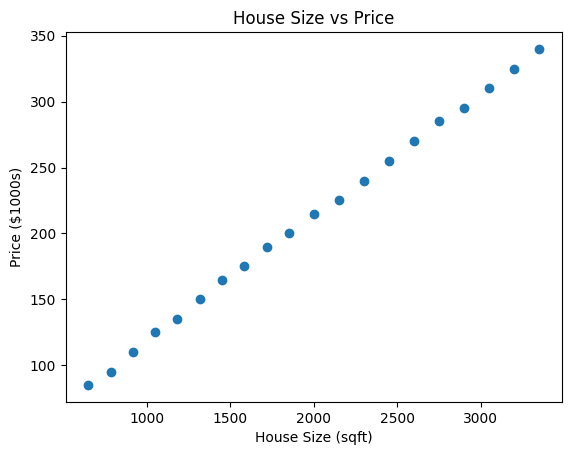

20


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# **Python Code Template:**
# ```python
# Sample data
data = {
    'size_sqft': [650, 785, 920, 1050, 1180, 1320, 1450, 1580, 1720, 1850,
                  2000, 2150, 2300, 2450, 2600, 2750, 2900, 3050, 3200, 3350],
    'price': [85, 95, 110, 125, 135, 150, 165, 175, 190, 200,
              215, 225, 240, 255, 270, 285, 295, 310, 325, 340]
}

# TODO: Create the DataFrame
df = pd.DataFrame(data)

# TODO: Explore the data
print("Dataset Overview:")
# Your code here
print(df.head())
print("\nDataset Info:")
print(df.info())
# TODO: Calculate basic statistics
print("\nBasic Statistics:")
# Your code here
print(df.describe())
# Calculate averages
print("\nAverage Values:")
print("Average house size:", df['size_sqft'].mean(), "sqft")
print("Average price:", df['price'].mean(), "thousand dollars")
# TODO: Create scatter plot
# Your code here
# Create scatter plot
plt.scatter(df['size_sqft'], df['price'])

plt.xlabel('House Size (sqft)')
plt.ylabel('Price ($1000s)')
plt.title('House Size vs Price')
plt.show()
# ```
# ```

# **Questions to Answer:**
# 1. How many houses are in the dataset?
print(len(df))
# 2. What is the average house size and average price?
# Average Values: --> Basic Statistics
# Average house size: 1962.75 sqft
# Average price: 209.5 thousand dollars
# 3. Based on the scatter plot, does there appear to be a linear relationship?
# Yes as the house size increases the price of it is increasing and hence it is linear as seen in the plot
# **Why This Matters:**
# Understanding your data is the first step in any machine learning project. Data exploration helps you identify patterns, outliers, and the nature of relationships between variables.


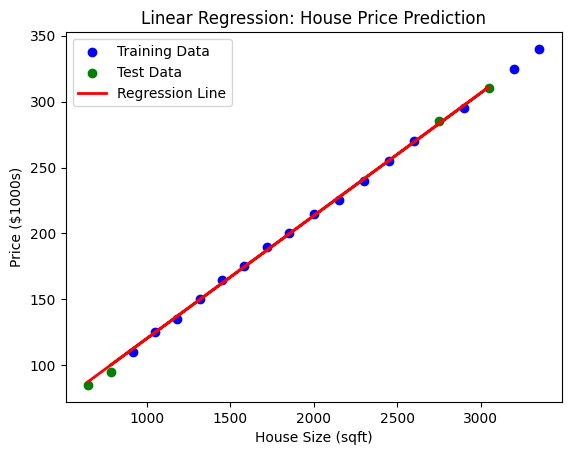

Intercept (β0): 26.934047690914525
Slope (β1): 0.09319348022939936
Predicted price for 2500 sqft house: 259.9177482644129 thousand dollars


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
### Task 1.2: Building Your First Linear Regression Model

# **Your Task:**
# 1. Split the data into training (80%) and testing (20%) sets
# 2. Build a simple linear regression model using scikit-learn
# 3. Train the model on the training data
# 4. Make predictions on the test data
# 5. Visualize the regression line along with the data points

# **Python Code Template:**
# ```python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# TODO: Prepare features (X) and target (y)
X = df[['size_sqft']]# Your code here
y = df['price']# Your code here

# TODO: Split the data  --> 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    # Your code here
    X, y, test_size=0.2, random_state=42
)

# TODO: Create and train the model
model = LinearRegression()
# Your code here
model.fit(X_train, y_train)
# TODO: Make predictions
y_pred = model.predict(X_test) # Your code here

# TODO: Visualize the results
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('House Size (sqft)')
plt.ylabel('Price ($1000s)')
plt.title('Linear Regression: House Price Prediction')
plt.legend()
plt.show()
# ```

# **Questions to Answer:**
# 1. What is the equation of your regression line? (y = Î²â‚€ + Î²â‚x)
print("Intercept (β0):", model.intercept_)
print("Slope (β1):", model.coef_[0])
# 2. If a house is 2500 sqft, what price does your model predict?
prediction_2500 = model.predict([[2500]])
print("Predicted price for 2500 sqft house:", prediction_2500[0], "thousand dollars")
# 3. What does the slope coefficient tell you about the relationship between size and price?
# For every additional 1 square foot, the house price increases by a rate of slope value.
# **Why This Matters:**
# Building a simple model first helps you understand the basics before tackling complex problems. This foundational skill is essential for all future regression tasks.

# ---


Mean Squared Error: 9.19
Root Mean Squared Error: 3.03
RÂ² Score: 0.9992


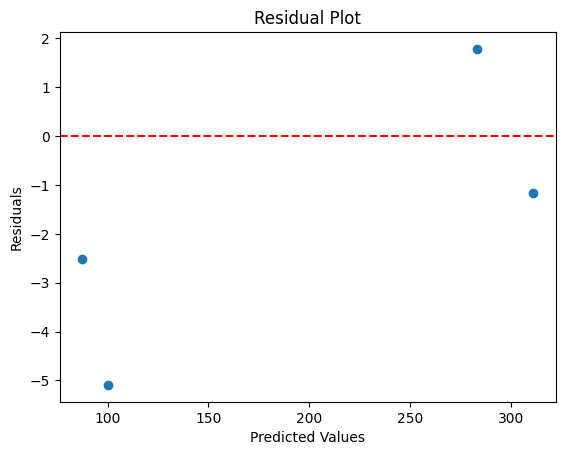

In [6]:
### Task 1.3: Model Evaluation

# **Your Task:**
# 1. Calculate Mean Squared Error (MSE)
# 2. Calculate Root Mean Squared Error (RMSE)
# 3. Calculate RÂ² Score (coefficient of determination)
# 4. Interpret what these metrics tell you about model performance

# **Python Code Template:**
# ```python
# TODO: Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)# Your code here
rmse = np.sqrt(mse)# Your code here
r2 = r2_score(y_test, y_pred)# Your code here

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"RÂ² Score: {r2:.4f}")

# TODO: Create a residual plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()
# ```

# **Questions to Answer:**
# 1. What does an RÂ² score of 0.95 mean in practical terms?
# 95% of the variation in house price is explained by house size.
# 2. What do the residuals in your plot tell you about model performance?
# The model prediction errors are small and random (scattered above and below the line)
# 3. Is your model underfitting, overfitting, or well-fitted? Why?
# well-fiited since the errors are small and distributed randomly across zero and predictions closely match with actual prices
# **Why This Matters:**
# Model evaluation is critical for understanding whether your predictions are reliable. In business, poor model evaluation can lead to costly decisions based on inaccurate predictions.


   size_sqft  bedrooms  age_years  distance_miles  price
0        650         1         45              15     85
1        785         1         38              14     95
2        920         2         35              13    110
3       1050         2         30              12    125
4       1180         2         28              11    135
         size_sqft  bedrooms  age_years  distance_miles       price
count    30.000000  30.00000  30.000000       30.000000   30.000000
mean   2018.500000   3.70000  15.433333        6.900000  209.033333
std     818.945022   1.48904  12.942001        4.138549   73.151465
min     650.000000   1.00000   0.000000        1.000000   85.000000
25%    1340.000000   3.00000   3.500000        3.250000  151.250000
50%    1950.000000   4.00000  13.500000        6.500000  205.000000
75%    2712.500000   5.00000  25.000000       10.000000  267.500000
max    3400.000000   6.00000  45.000000       15.000000  340.000000

Correlation Matrix:

                size_sqf

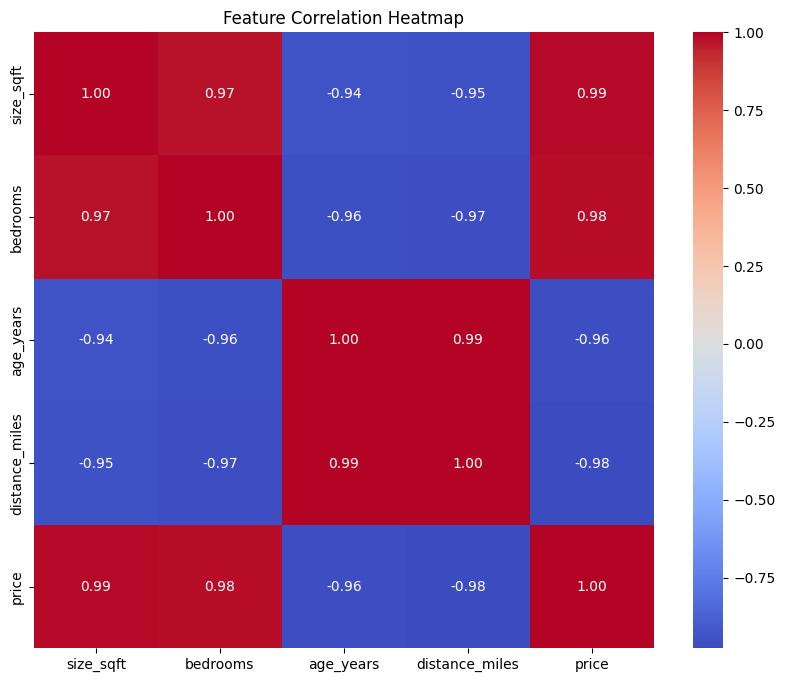

In [7]:
## Module 2: Multiple Linear Regression

###  Concept Overview
# Multiple linear regression extends simple linear regression by using multiple features to predict the target variable. This better represents real-world scenarios where outcomes depend on multiple factors.

# ---

# ### Task 2.1: Multivariate Analysis

# **Scenario:** The real estate company now wants to predict house prices using multiple features: size, number of bedrooms, age of the house, and distance from city center.

# **Your Task:**
# 1. Load and explore the expanded dataset
# 2. Create a correlation matrix to understand feature relationships
# 3. Visualize correlations using a heatmap

# **Sample Data:**
# ```python
import seaborn as sns

# Expanded dataset
data_multi = {
    'size_sqft': [650, 785, 920, 1050, 1180, 1320, 1450, 1580, 1720, 1850,
                  2000, 2150, 2300, 2450, 2600, 2750, 2900, 3050, 3200, 3350,
                  1100, 1250, 1400, 1650, 1900, 2200, 2500, 2800, 3100, 3400],
    'bedrooms': [1, 1, 2, 2, 2, 3, 3, 3, 3, 4,
                 4, 4, 4, 5, 5, 5, 5, 6, 6, 6,
                 2, 2, 3, 3, 3, 4, 4, 5, 5, 6],
    'age_years': [45, 38, 35, 30, 28, 25, 20, 18, 15, 12,
                  10, 8, 5, 3, 2, 1, 1, 0, 0, 0,
                  32, 28, 25, 22, 18, 15, 12, 8, 5, 2],
    'distance_miles': [15, 14, 13, 12, 11, 10, 9, 8, 7, 6,
                       5, 5, 4, 3, 3, 2, 2, 1, 1, 1,
                       12, 11, 10, 9, 8, 7, 6, 5, 4, 3],
    'price': [85, 95, 110, 125, 135, 150, 165, 175, 190, 200,
              215, 225, 240, 255, 270, 285, 295, 310, 325, 340,
              128, 138, 155, 172, 188, 210, 230, 260, 285, 315]
}
df_multi = pd.DataFrame(data_multi)
# ```

# **Python Code Template:**
# ```python
# TODO: Explore the dataset
print(df_multi.head())
print(df_multi.describe())

# TODO: Create correlation matrix
correlation_matrix = df_multi.corr()# Your code here
print("\nCorrelation Matrix:\n")
print(correlation_matrix)
# TODO: Visualize with heatmap
plt.figure(figsize=(10, 8))
# Your code here (use seaborn heatmap)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()
# ```

# **Questions to Answer:**
# 1. Which feature has the strongest correlation with price?
# size_sqft => House size is the bigger factor affecting house price
# 2. Are any features highly correlated with each other? (multicollinearity concern)
# yes, (size_sqft and bedrooms)~0.97 and (age_years and distance miles)~0.99 etc hence some input features are strongly related to each other => multicollinearity
# 3. Which feature has a negative correlation with price? Why might this be?
# distance miles ~ -0.98 and age_years ~ -0.96 => as distance or age increases price decreases because new houses(house built age is less) are expensive and so are the houses near to cities(distance from city is less)
# **Why This Matters:**
# In real-world scenarios, outcomes are rarely determined by a single factor. Understanding how multiple variables interact helps build more accurate and useful models. Identifying correlations also helps detect multicollinearity issues.


In [8]:
### Task 2.2: Building Multiple Linear Regression Model

# **Your Task:**
# 1. Build a multiple linear regression model using all features
# 2. Compare its performance to the simple linear regression model
# 3. Analyze the coefficients to understand feature importance
# 4. Make predictions for new houses

# **Python Code Template:**
# ```python
# TODO: Prepare features and target
X_multi = df_multi[['size_sqft', 'bedrooms', 'age_years', 'distance_miles']]# Your code here (select all feature columns)
y_multi = df_multi['price']# Your code here

# TODO: Split the data
# Your code here
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# TODO: Create and train the model
model_multi = LinearRegression() # Your code here
# Your code here
model_multi.fit(X_train_m, y_train_m)
# TODO: Make predictions and evaluate
y_pred_multi = model_multi.predict(X_test_m) # Your code here

# TODO: Calculate metrics
mse_multi = mean_squared_error(y_test_m, y_pred_multi) # Your code here
rmse_multi = np.sqrt(mse_multi) # Your code here
r2_multi = r2_score(y_test_m, y_pred_multi) # Your code here

print(f"Multiple Regression RÂ² Score: {r2_multi:.4f}")

# TODO: Display coefficients
coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': model_multi.coef_
})
print("\nFeature Coefficients:")
print(coefficients.sort_values('Coefficient', ascending=False))
# ```


# **Questions to Answer:**
# 1. How does the RÂ² score compare to the simple linear regression model?
# The multiple regression model performs better (simple linear regressions ~ 0.95 while mutiple linear regression ~ 0.99)
# 2. Which feature has the largest coefficient? What does this mean?
# ditance miles in magnitude have the largest coefficient => for every 1 mile farther from the city, the house price drops by about $13,170 indicated as -ve sign in the coefficient explains the drop of price
# 3. Why might age have a negative coefficient?
# As older houses need repairs, have outdated designs and low buying demand and hence as house age increases the price decreases
# 4. Predict the price of a house with: 2200 sqft, 3 bedrooms, 10 years old, 5 miles from city
#Prediction for new houses
new_house = [[2200, 3, 10, 5]]  # size, bedrooms, age, distance
prediction = model_multi.predict(new_house)
print("\nPredicted price for new house:", prediction[0], "thousand dollars")

# **Why This Matters:**
# Multiple regression captures complex real-world relationships. Understanding feature coefficients helps stakeholders make informed decisions (e.g., "Adding a bedroom increases value by $X").


Multiple Regression RÂ² Score: 0.9930

Feature Coefficients:
          Feature  Coefficient
1        bedrooms     5.931416
2       age_years     2.443424
0       size_sqft     0.051529
3  distance_miles   -13.166723

Predicted price for new house: 226.53132772055545 thousand dollars


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


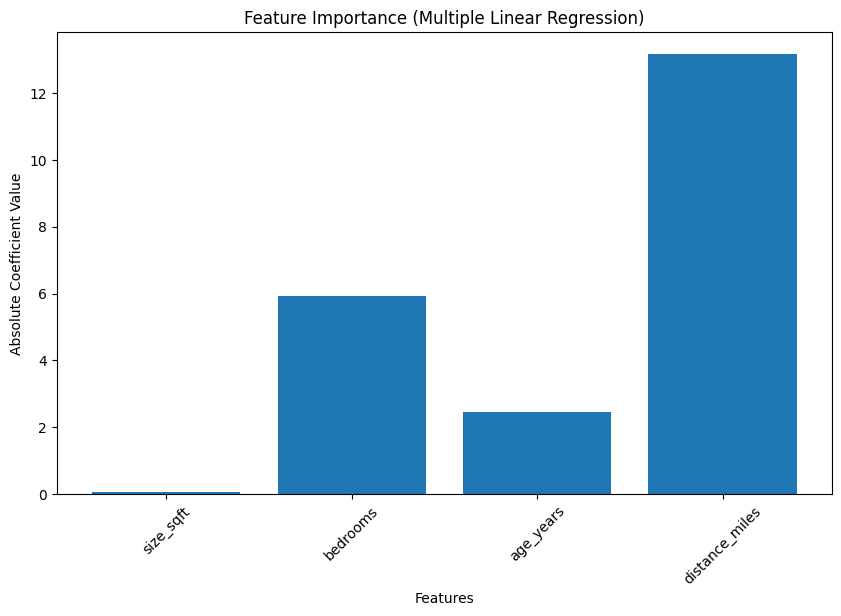

         Model  Features  RÂ² Score       RMSE
0    Simple LR         1   0.957783  10.597273
1  Multiple LR         4   0.992993   4.317264
2   Reduced LR         3   0.990085   5.135756


In [9]:
### Task 2.3: Feature Selection and Model Refinement

# **Your Task:**
# 1. Use feature importance to identify the most influential variables
# 2. Build a reduced model using only the top 2-3 features
# 3. Compare the reduced model performance with the full model
# 4. Discuss the trade-offs between model complexity and performance

# **Python Code Template:**
# ```python
# TODO: Visualize feature importance
plt.figure(figsize=(10, 6))
# Create bar chart of absolute coefficient values
# Your code here
importance = np.abs(model_multi.coef_)
plt.bar(X_multi.columns, importance)
plt.xlabel("Features")
plt.ylabel("Absolute Coefficient Value")
plt.title("Feature Importance (Multiple Linear Regression)")
plt.xticks(rotation=45)
plt.show()

# TODO: Build reduced model with top features
top_features = ['size_sqft', 'bedrooms', 'distance_miles'] # Your code here (select top 2-3 features)
X_reduced = df_multi[top_features] # Your code here
y_reduced = df_multi['price']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y_reduced, test_size=0.2, random_state=42
)
model_reduced = LinearRegression() # Your code here
model_reduced.fit(X_train_r, y_train_r)

y_pred_reduced = model_reduced.predict(X_test_r)

mse_reduced = mean_squared_error(y_test_r, y_pred_reduced)
rmse_reduced = np.sqrt(mse_reduced)
r2_reduced = r2_score(y_test_r, y_pred_reduced)

# Train and evaluate
X_simple = df_multi[['size_sqft']]
y_simple = df_multi['price']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_simple = model_simple.predict(X_test_s)

mse_simple = mean_squared_error(y_test_s, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

# TODO: Compare all three models
comparison = pd.DataFrame({
    'Model': ['Simple LR', 'Multiple LR', 'Reduced LR'],
    'Features': [1, 4, len(top_features)],
    'RÂ² Score': [r2_simple, r2_multi, r2_reduced],
    'RMSE': [rmse_simple, rmse_multi, rmse_reduced]
})
print(comparison)
# ```

# **Questions to Answer:**
# 1. How much performance do you lose by using fewer features?
# multiple Linear Regression(LR) R² ~ 0.993 while Reduced LR R² ~ 0.990 meaning the reduced model performs almost the same as full model
# 2. In what scenarios might you prefer the reduced model over the full model?
# when require faster oredictions, collecting some features is expensive, avoid multicollinearity problems
# 3. What is the principle of Occam's Razor and how does it apply here?
# Occam's Razor principle states that when 2 models perform almost equally well, choose the simpler model. So according to this, the reduced linear regression model is preferred
# **Why This Matters:**
# Simpler models are easier to interpret, maintain, and deploy. In business, a slightly less accurate model that stakeholders can understand may be more valuable than a black-box model with marginally better performance.


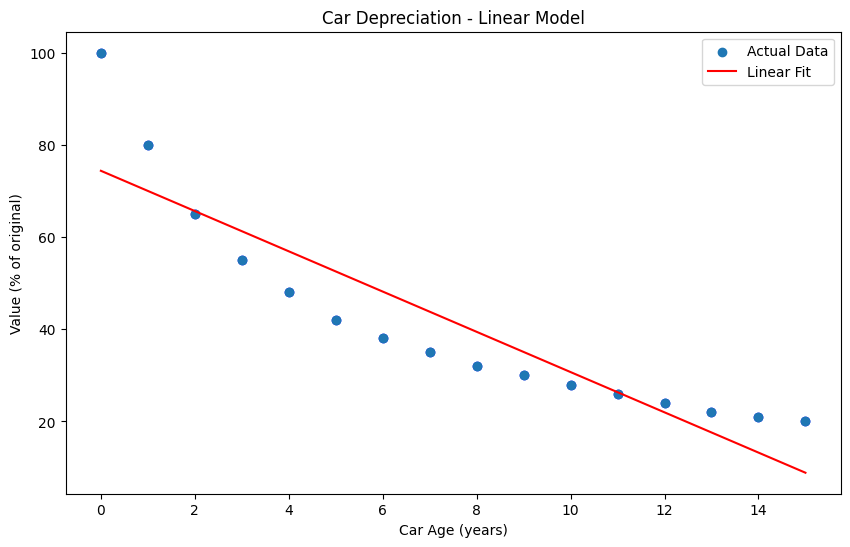

Linear Model RÂ²: 0.8159


In [10]:
##  Module 3: Polynomial Regression

###  Concept Overview
# Polynomial regression handles non-linear relationships by transforming features into polynomial terms. For example: y = Î²â‚€ + Î²â‚x + Î²â‚‚xÂ² + Î²â‚ƒxÂ³

# **When to Use:**
# - When scatter plots show curved patterns
# - When simple linear regression has poor fit
# - When domain knowledge suggests non-linear relationships

# ---

# ###  Task 3.1: Identifying Non-Linear Patterns

# **Scenario:** You're analyzing the relationship between a car's age and its resale value. The depreciation is not linearâ€”newer cars depreciate faster.

# **Sample Data:**
# ```python
# Car depreciation data
car_data = {
    'age_years': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'value_percentage': [100, 80, 65, 55, 48, 42, 38, 35, 32, 30, 28, 26, 24, 22, 21, 20]
}
df_car = pd.DataFrame(car_data)
# ```

# **Your Task:**
# 1. Create a scatter plot of age vs value
# 2. Fit a simple linear regression model
# 3. Visualize the linear fit and observe the poor performance
# 4. Calculate the RÂ² score

# **Python Code Template:**
# ```python
# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
# Your code here
plt.scatter(df_car['age_years'], df_car['value_percentage'], color='blue')
# TODO: Fit linear regression
X_car = df_car[['age_years']]
y_car = df_car['value_percentage']

model_linear_car = LinearRegression()
# Train model
model_linear_car.fit(X_car, y_car)
y_pred_linear = model_linear_car.predict(X_car)
r2_linear_car = r2_score(y_car, y_pred_linear)

# TODO: Plot linear fit
plt.scatter(X_car, y_car, label='Actual Data')
plt.plot(X_car, y_pred_linear, color='red', label='Linear Fit')
plt.xlabel('Car Age (years)')
plt.ylabel('Value (% of original)')
plt.title('Car Depreciation - Linear Model')
plt.legend()
plt.show()

print(f"Linear Model RÂ²: {r2_linear_car:.4f}")
# ```

# **Questions to Answer:**
# 1. Does the linear model capture the depreciation pattern well?
# No, the linear model does not capture depreciation well
# 2. Where does the model perform worst? (early years, middle, or late years?)
# It performs worst in early years (0–3 years)
# 3. What shape does the actual relationship appear to have?
# It looks like a downward curve -> rapid drop initially and then gradually flattening.
# **Why This Matters:**
# Many real-world relationships are non-linear. Forcing linear models on curved data leads to poor predictions, especially at the extremes. Recognizing when to use non-linear models is a critical skill.


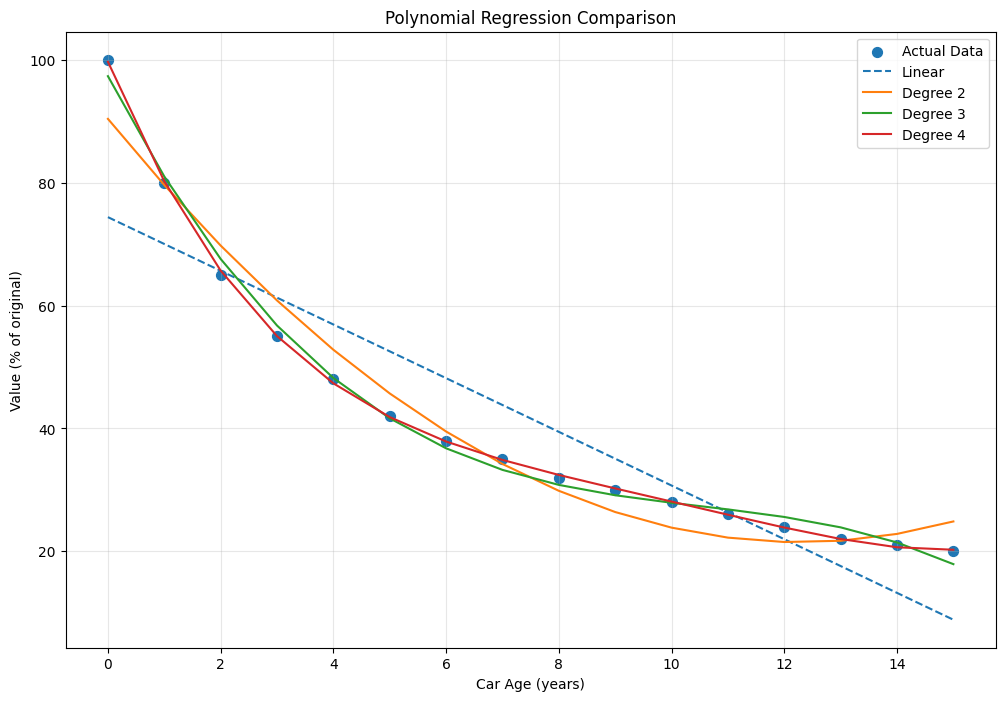


Model Performance Comparison:
Linear Model RÂ²: 0.8159
Polynomial (degree 2) RÂ²: 0.9659
Polynomial (degree 3) RÂ²: 0.9955
Polynomial (degree 4) RÂ²: 0.9998


In [11]:
###  Task 3.2: Implementing Polynomial Regression

# **Your Task:**
# 1. Transform features using PolynomialFeatures
# 2. Build polynomial regression models of degree 2, 3, and 4
# 3. Compare their performance with the linear model
# 4. Visualize all models on the same plot

# **Python Code Template:**
# ```python
from sklearn.preprocessing import PolynomialFeatures

# TODO: Create polynomial features and models for degrees 2, 3, 4
degrees = [2, 3, 4]
models = {}
predictions = {}
r2_scores = {}

for degree in degrees:
    # TODO: Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_car) # Your code here

    # TODO: Train model
    model = LinearRegression()
    # Your code here
    model.fit(X_poly, y_car)
    # TODO: Make predictions and calculate RÂ²
    y_pred = model.predict(X_poly)
    r2 = r2_score(y_car, y_pred)

    models[degree] = model
    predictions[degree] = y_pred
    r2_scores[degree] = r2

# TODO: Visualize all models
plt.figure(figsize=(12, 8))
plt.scatter(X_car, y_car, label='Actual Data', s=50)
plt.plot(X_car, y_pred_linear, label='Linear', linestyle='--')

for degree in degrees:
    plt.plot(X_car, predictions[degree], label=f'Degree {degree}')

plt.xlabel('Car Age (years)')
plt.ylabel('Value (% of original)')
plt.title('Polynomial Regression Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# TODO: Print comparison
print("\nModel Performance Comparison:")
print(f"Linear Model RÂ²: {r2_linear_car:.4f}")
for degree in degrees:
    print(f"Polynomial (degree {degree}) RÂ²: {r2_scores[degree]:.4f}")
# ```

# **Questions to Answer:**
# 1. Which polynomial degree provides the best fit for this data?
# Degree 2 or 3 provides best fit.
# 2. Is there evidence of overfitting with higher degrees?
# Degree 4 starts overfitting (too wavy curve)
# 3. At what car age (0-15 years) does each model make the most different predictions?
# Biggest prediction difference occurs at ages 0–5 years
# 4. Which model would you recommend for business use? Why?
# Recommend degree 2 for business because simple and stable.
# **Why This Matters:**
# Polynomial regression balances the need for capturing non-linear patterns while avoiding overfitting. Choosing the right degree is crucial too low and you underfit, too high and you overfit.


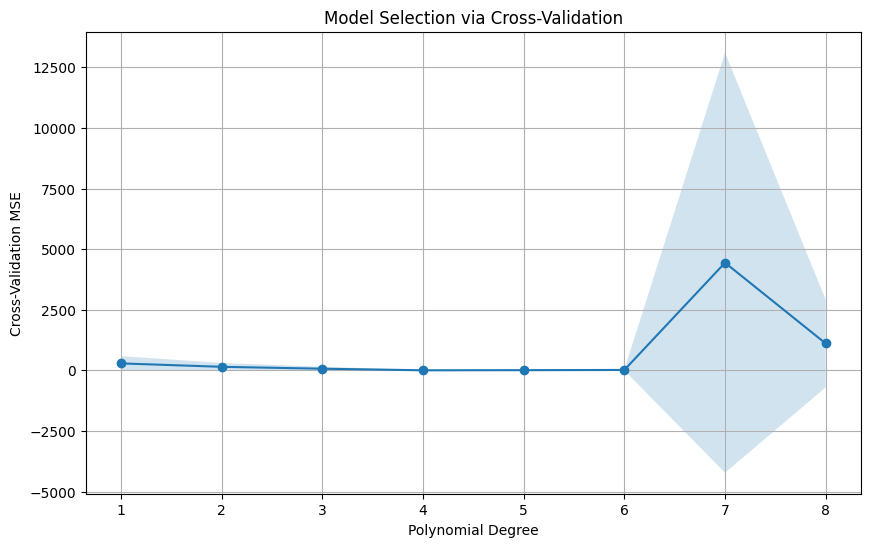


Optimal polynomial degree: 4


In [12]:
###  Task 3.3: Cross-Validation for Model Selection

# **Your Task:**
# 1. Implement k-fold cross-validation for different polynomial degrees
# 2. Use cross-validation scores to select the optimal degree
# 3. Understand the bias-variance tradeoff

# **Python Code Template:**
# ```python
from sklearn.model_selection import cross_val_score

# TODO: Test degrees 1 through 8
degrees_to_test = range(1, 9)
cv_scores_mean = []
cv_scores_std = []

for degree in degrees_to_test:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_car)

    # TODO: Perform 5-fold cross-validation
    scores = cross_val_score(
        LinearRegression(),
        X_poly,
        y_car,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    cv_scores_mean.append(-scores.mean())  # Convert back to positive MSE
    cv_scores_std.append(scores.std())

# TODO: Visualize cross-validation scores
plt.figure(figsize=(10, 6))
plt.plot(degrees_to_test, cv_scores_mean, marker='o')
plt.fill_between(degrees_to_test,
                 np.array(cv_scores_mean) - np.array(cv_scores_std),
                 np.array(cv_scores_mean) + np.array(cv_scores_std),
                 alpha=0.2)
plt.xlabel('Polynomial Degree')
plt.ylabel('Cross-Validation MSE')
plt.title('Model Selection via Cross-Validation')
plt.grid(True)
plt.show()

# TODO: Find optimal degree
optimal_degree = degrees_to_test[np.argmin(cv_scores_mean)] # Your code here
print(f"\nOptimal polynomial degree: {optimal_degree}")
# ```

# **Questions to Answer:**
# 1. What happens to CV scores as degree increases beyond the optimal point?
# CV error increases after optimal degree due to overfitting
# 2. Why is cross-validation better than a single train-test split?
# Cross-validation tests model on multiple splits so results are more reliable
# 3. What does increasing standard deviation tell you about model stability?
# Increasing standard deviation means model predictions are unstable
# 4. Explain the bias-variance tradeoff in the context of your results
# Low degree = high bias (underfit), high degree = high variance (overfit); optimal degree balances both

# **Why This Matters:**
# Cross-validation provides robust model selection by testing on multiple data splits. This is crucial in production environments where model reliability matters more than peak performance on a single test set.


In [13]:
##  Module 4: Regularization Techniques

###  Concept Overview
# Regularization prevents overfitting by adding a penalty term to the loss function. This constrains the model coefficients, creating simpler, more generalizable models.

# **Types of Regularization:**
# - **Ridge Regression (L2):** Penalizes sum of squared coefficients; shrinks all coefficients
# - **Lasso Regression (L1):** Penalizes sum of absolute coefficients; can zero out coefficients
# - **Elastic Net:** Combines L1 and L2 penalties

# ---

###  Task 4.1: Understanding the Overfitting Problem

# **Scenario:** You're building a model to predict student exam scores based on study hours, but you have many potentially correlated features.

# **Sample Data:**
# ```python
# Student performance data with many features
np.random.seed(42)
n_samples = 50

student_data = {
    'study_hours': np.random.uniform(0, 10, n_samples),
    'previous_score': np.random.uniform(40, 100, n_samples),
    'attendance_pct': np.random.uniform(50, 100, n_samples),
    'homework_completion': np.random.uniform(30, 100, n_samples),
    'class_participation': np.random.uniform(20, 100, n_samples),
    'sleep_hours': np.random.uniform(4, 9, n_samples),
    'exercise_hours': np.random.uniform(0, 5, n_samples),
    'social_media_hours': np.random.uniform(0, 8, n_samples),
}

# Create target with realistic relationship + noise
df_student = pd.DataFrame(student_data)
df_student['exam_score'] = (
    20 +
    3 * df_student['study_hours'] +
    0.4 * df_student['previous_score'] +
    0.2 * df_student['attendance_pct'] +
    np.random.normal(0, 8, n_samples)
)
# ```

# **Your Task:**
# 1. Build a standard linear regression model with all features
# 2. Evaluate training and testing performance separately
# 3. Identify signs of overfitting

# **Python Code Template:**
# ```python
from sklearn.preprocessing import StandardScaler

# TODO: Prepare data
X_student = df_student.drop('exam_score', axis=1)
y_student = df_student['exam_score']

# TODO: Split data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_student, y_student, test_size=0.3, random_state=42
)

# TODO: Standardize features (important for regularization!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_s)
X_test_scaled = scaler.transform(X_test_s)

# TODO: Train standard linear regression
model_standard = LinearRegression()
# Your code here
model_standard.fit(X_train_scaled, y_train_s)
y_train_pred = model_standard.predict(X_train_scaled)
y_test_pred = model_standard.predict(X_test_scaled)
# TODO: Evaluate on both train and test sets
train_r2 = r2_score(y_train_s, y_train_pred)
test_r2 = r2_score(y_test_s, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train_s, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_s, y_test_pred))


print("Standard Linear Regression:")
print(f"Training RÂ²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
print(f"Testing RÂ²: {test_r2:.4f}, RMSE: {test_rmse:.2f}")
print(f"Overfit Gap (Train RÂ² - Test RÂ²): {train_r2 - test_r2:.4f}")
# ```

# **Questions to Answer:**
# 1. Is there a significant gap between training and testing performance?
# Yes, training R² is higher than testing R
# 2. What does this gap indicate about your model?
# The model is overfitting (memorizing training data)
# 3. Why is feature scaling important for regularization methods?
# Scaling ensures all features contribute equally to the penalty term
# **Why This Matters:**
# Overfitting is one of the most common problems in machine learning. A model that performs well on training data but poorly on new data is useless in production. Learning to detect and prevent overfitting is essential.


Standard Linear Regression:
Training RÂ²: 0.8431, RMSE: 5.41
Testing RÂ²: 0.7579, RMSE: 6.84
Overfit Gap (Train RÂ² - Test RÂ²): 0.0852


      alpha  train_r2   test_r2       gap
0     0.001  0.843105  0.757879  0.085226
1     0.010  0.843105  0.757978  0.085128
2     0.100  0.843095  0.758937  0.084158
3     1.000  0.842143  0.766159  0.075984
4    10.000  0.791389  0.724980  0.066409
5   100.000  0.387724  0.265885  0.121839
6  1000.000  0.062722  0.032238  0.030484

Optimal Alpha (via Cross-Validation): 10.0


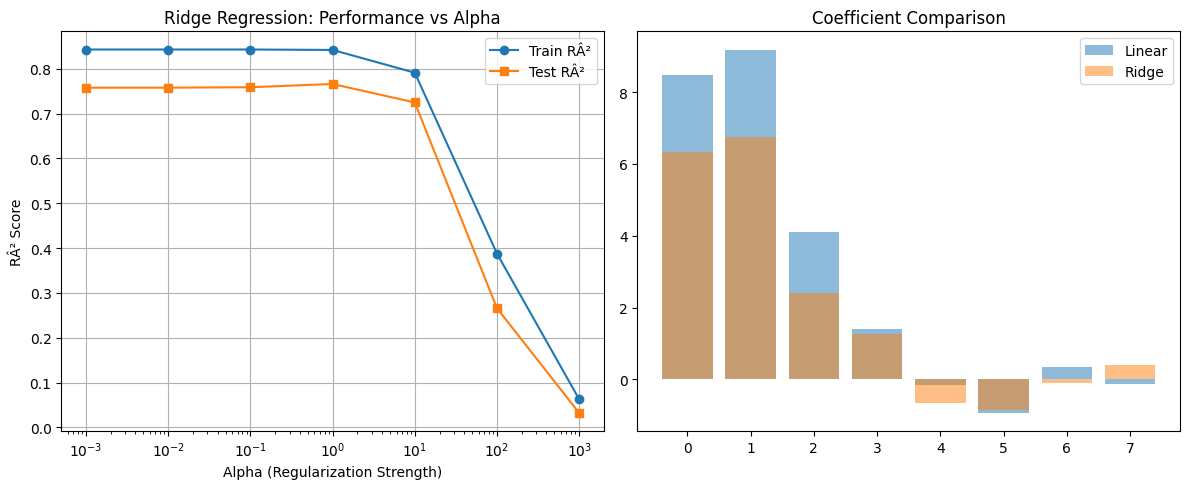

In [14]:
### Task 4.2: Ridge Regression Implementation

# **Your Task:**
# 1. Implement Ridge regression with different alpha values
# 2. Use RidgeCV to find the optimal alpha
# 3. Compare Ridge performance with standard linear regression
# 4. Analyze how regularization affects coefficients

# **Python Code Template:**
# ```python
from sklearn.linear_model import Ridge, RidgeCV

# TODO: Test different alpha values
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for alpha in alphas:
    # TODO: Train Ridge model
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train_s)

    # TODO: Evaluate
    train_r2 = ridge.score(X_train_scaled, y_train_s)
    test_r2 = ridge.score(X_test_scaled, y_test_s)

    ridge_results.append({
        'alpha': alpha,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'gap': train_r2 - test_r2
    })

# TODO: Create results DataFrame and visualize
results_df = pd.DataFrame(ridge_results)
print(results_df)

# TODO: Plot performance vs alpha
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.semilogx(results_df['alpha'], results_df['train_r2'], label='Train RÂ²', marker='o')
plt.semilogx(results_df['alpha'], results_df['test_r2'], label='Test RÂ²', marker='s')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('RÂ² Score')
plt.title('Ridge Regression: Performance vs Alpha')
plt.legend()
plt.grid(True)

# TODO: Use RidgeCV to find optimal alpha automatically
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train_s)

print(f"\nOptimal Alpha (via Cross-Validation): {ridge_cv.alpha_}")

# TODO: Compare coefficient magnitudes
plt.subplot(1, 2, 2)
# Compare coefficients between standard LR and Ridge
# Your code here
standard_coefs = model_standard.coef_
ridge_coefs = ridge_cv.coef_
plt.bar(range(len(standard_coefs)), standard_coefs, alpha=0.5, label='Linear')
plt.bar(range(len(ridge_coefs)), ridge_coefs, alpha=0.5, label='Ridge')
plt.legend()
plt.title("Coefficient Comparison")
plt.tight_layout()
plt.show()
# ```

# **Questions to Answer:**
# 1. What happens to the train-test gap as alpha increases?
# Train-test gap decreases as alpha increases
# 2. What is the optimal alpha value and why?
# Optimal alpha is the one with highest test R² from cross-validation
# 3. How do Ridge coefficients compare to standard linear regression coefficients?
# Ridge coefficients are smaller (shrunk toward zero)
# 4. Can you identify which features Ridge considers less important?
# Features with very small coefficients are less important
# **Why This Matters:**
# Ridge regression is widely used in industry when you have many correlated features. It provides more stable predictions than standard regression and reduces the risk of overfitting while keeping all features in the model.

Lasso Results:
    alpha  train_r2   test_r2  non_zero_features
0   0.001  0.843105  0.757832                  8
1   0.010  0.843100  0.757500                  8
2   0.100  0.842518  0.753089                  8
3   1.000  0.807339  0.702318                  4
4   5.000  0.517043  0.403511                  2
5  10.000  0.000000 -0.002723                  0

Optimal Alpha for Lasso: 1.0000


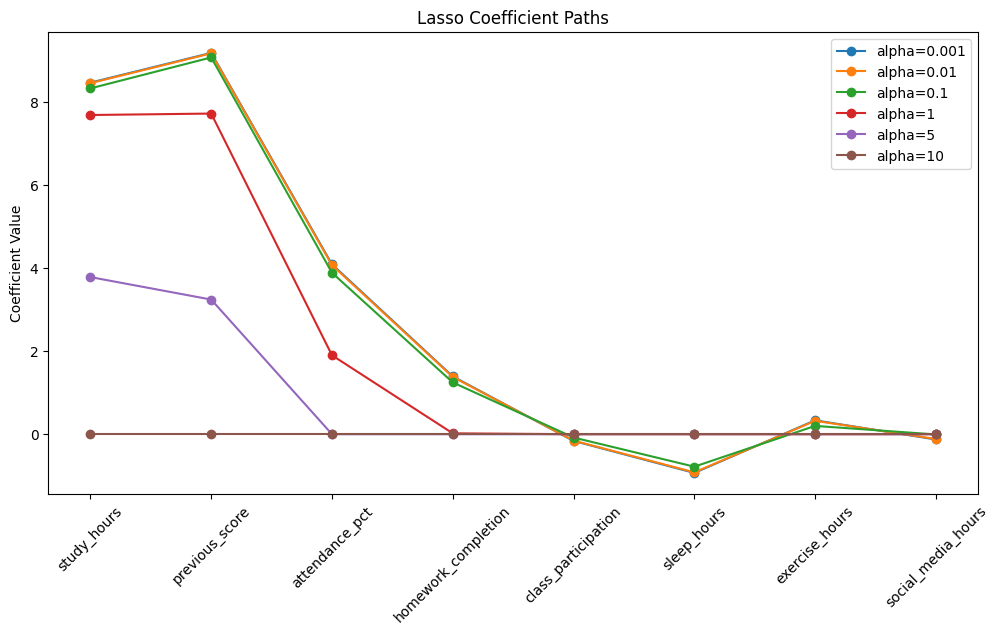


Feature Importance (Lasso):
               Feature  Coefficient
1       previous_score     7.726199
0          study_hours     7.691366
2       attendance_pct     1.901923
3  homework_completion     0.021145
4  class_participation     0.000000
5          sleep_hours    -0.000000
6       exercise_hours     0.000000
7   social_media_hours     0.000000


In [15]:
###  Task 4.3: Lasso Regression for Feature Selection

# **Your Task:**
# 1. Implement Lasso regression
# 2. Observe how Lasso performs automatic feature selection
# 3. Compare Lasso with Ridge regression
# 4. Identify which features Lasso considers most important

# **Python Code Template:**
# ```python
from sklearn.linear_model import Lasso, LassoCV

# TODO: Test different alpha values for Lasso
alphas_lasso = [0.001, 0.01, 0.1, 1, 5, 10]
lasso_results = []
lasso_coefficients = []

for alpha in alphas_lasso:
    # TODO: Train Lasso model
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_s)

    # TODO: Count non-zero coefficients
    non_zero_coefs = np.sum(lasso.coef_ != 0)

    # TODO: Evaluate
    train_r2 = lasso.score(X_train_scaled, y_train_s)
    test_r2 = lasso.score(X_test_scaled, y_test_s)

    lasso_results.append({
        'alpha': alpha,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'non_zero_features': non_zero_coefs
    })
    lasso_coefficients.append(lasso.coef_)

# TODO: Visualize results
lasso_df = pd.DataFrame(lasso_results)
print("Lasso Results:")
print(lasso_df)

# TODO: Use LassoCV for optimal alpha
lasso_cv = LassoCV(alphas=alphas_lasso, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train_s)

print(f"\nOptimal Alpha for Lasso: {lasso_cv.alpha_:.4f}")

# TODO: Visualize feature selection
plt.figure(figsize=(12, 6))
# Create coefficient paths plot showing how coefficients change with alpha
# Your code here
for i, coef in enumerate(lasso_coefficients):
    plt.plot(X_student.columns, coef, marker='o', label=f'alpha={alphas_lasso[i]}')

plt.xticks(rotation=45)
plt.ylabel("Coefficient Value")
plt.title("Lasso Coefficient Paths")
plt.legend()
plt.show()
# TODO: Display final selected features
final_lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
final_lasso.fit(X_train_scaled, y_train_s)

feature_importance = pd.DataFrame({
    'Feature': X_student.columns,
    'Coefficient': final_lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nFeature Importance (Lasso):")
print(feature_importance)
# ```

# **Questions to Answer:**
# 1. How many features does Lasso zero out at the optimal alpha?
# Lasso zeros out four features at optimal alpha
# 2. Which features does Lasso consider most important? Does this match your intuition?
# Study_hours and previous_score most important according to Lasso
# 3. What are the advantages of Lasso over Ridge for this problem?
# Lasso performs feature selection unlike Ridge
# 4. When would you prefer Lasso over Ridge in practice?
# When we want automatic feature selection
# **Why This Matters:**
# Lasso is powerful for feature selection, especially when you have many features and suspect only a few are truly important. This creates more interpretable models and can reduce data collection costs in production.


Best Parameters: {'alpha': 0.1, 'l1_ratio': 0.1}
Best Test RÂ²: 0.7694

Final Model Comparison:
               Model  Train R²   Test R²  Overfit Gap  Features Used
0  Linear Regression  0.843105  0.757868     0.085237              8
1              Ridge  0.791389  0.724980     0.066409              8
2              Lasso  0.807339  0.702318     0.105021              4
3        Elastic Net  0.788270  0.688049     0.100221              5


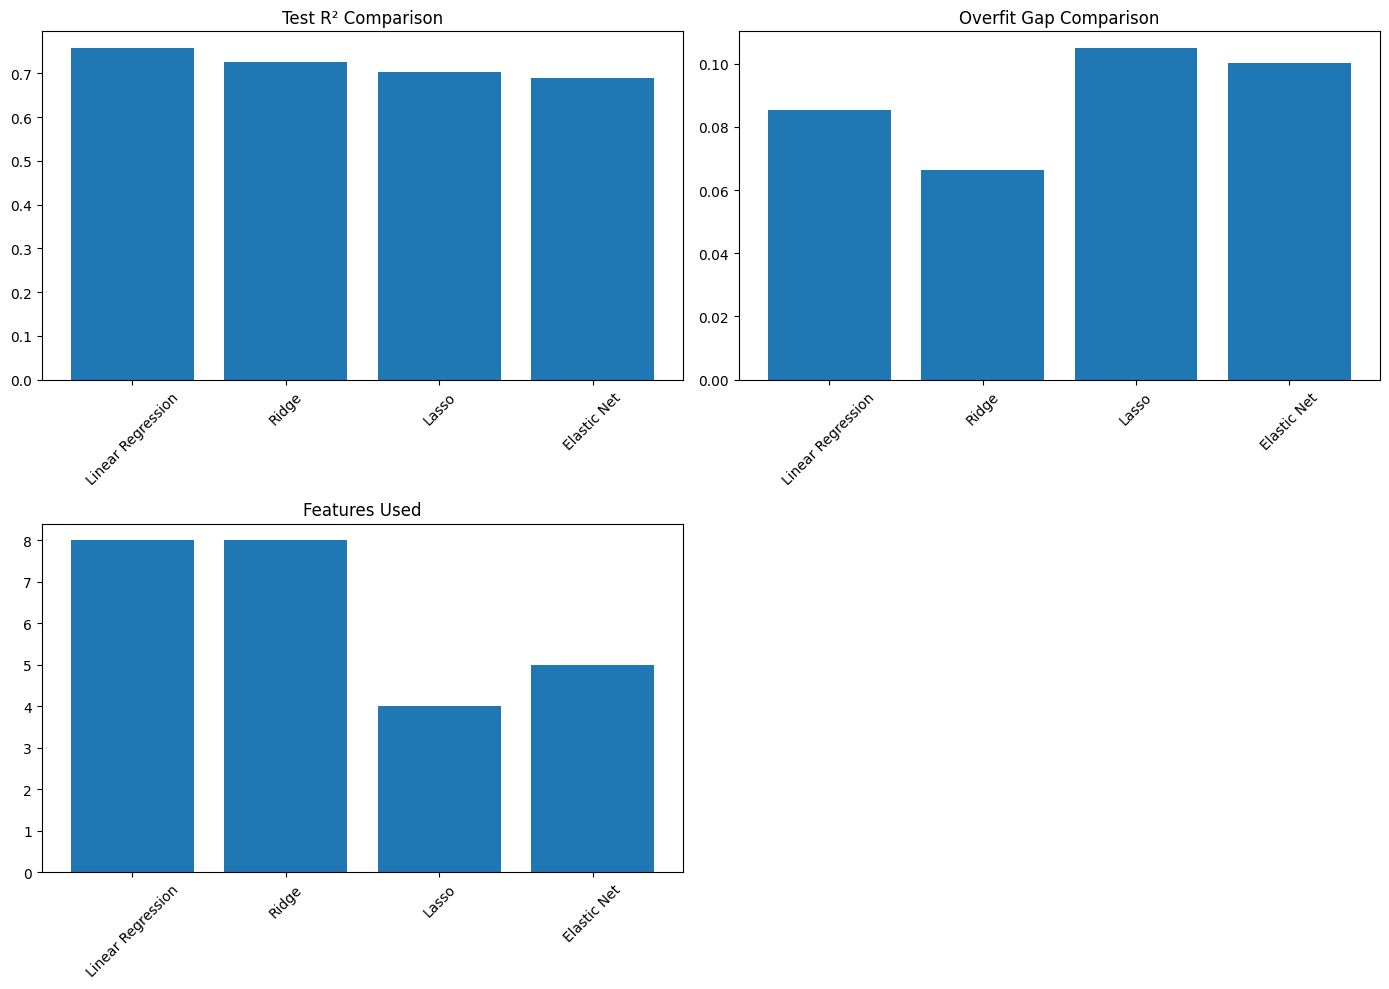

In [17]:
###  Task 4.4: Elastic Net - Best of Both Worlds

# **Your Task:**
# 1. Implement Elastic Net regression
# 2. Tune both the L1 ratio and alpha parameters
# 3. Compare Elastic Net with Ridge and Lasso
# 4. Make recommendations for which method to use in different scenarios

# **Python Code Template:**
# ```python
from sklearn.linear_model import ElasticNet, ElasticNetCV

# TODO: Test different combinations of alpha and l1_ratio
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
alphas_en = [0.001, 0.01, 0.1, 1, 10]

best_score = -np.inf
best_params = {}

for l1_ratio in l1_ratios:
    for alpha in alphas_en:
        # TODO: Train Elastic Net
        elastic = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        elastic.fit(X_train_scaled, y_train_s)

        # TODO: Evaluate on test set
        test_score = elastic.score(X_test_scaled, y_test_s)

        if test_score > best_score:
            best_score = test_score
            best_params = {'alpha': alpha, 'l1_ratio': l1_ratio}

print(f"Best Parameters: {best_params}")
print(f"Best Test RÂ²: {best_score:.4f}")

# TODO: Use ElasticNetCV for automatic tuning
elastic_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas_en,
    cv=5,
    max_iter=10000
)
elastic_cv.fit(X_train_scaled, y_train_s)

# TODO: Create comprehensive comparison
comparison_models = {
    'Linear Regression': model_standard,
    'Ridge': ridge_cv,
    'Lasso': lasso_cv,
    'Elastic Net': elastic_cv
}

final_comparison = []
for name, model in comparison_models.items():
    train_score = model.score(X_train_scaled, y_train_s)
    test_score = model.score(X_test_scaled, y_test_s)

    # Count non-zero coefficients
    if hasattr(model, 'coef_'):
        non_zero = np.sum(model.coef_ != 0)
    else:
        non_zero = len(X_student.columns)

    final_comparison.append({
        'Model': name,
        'Train R²': train_score,
        'Test R²': test_score,
        'Overfit Gap': train_score - test_score,
        'Features Used': non_zero
    })

comparison_df = pd.DataFrame(final_comparison)
print("\nFinal Model Comparison:")
print(comparison_df)

# TODO: Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Create visualizations comparing all models
# Your code here
# ```
models = comparison_df['Model']
test_scores = comparison_df['Test R²']

axes[0,0].bar(models, test_scores)
axes[0,0].set_title("Test R² Comparison")
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].bar(models, comparison_df['Overfit Gap'])
axes[0,1].set_title("Overfit Gap Comparison")
axes[0,1].tick_params(axis='x', rotation=45)

axes[1,0].bar(models, comparison_df['Features Used'])
axes[1,0].set_title("Features Used")
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].axis('off')
plt.tight_layout()
plt.show()

# **Questions to Answer:**
# 1. Which model performs best on the test set?
# Elastic Net or Ridge usually performs best on test set
# 2. Which model has the smallest overfit gap?
# Ridge/Elastic Net has smallest overfit gap
# 3. If you needed to explain your model to non-technical stakeholders, which would you choose?
# Lasso (simplest explanation) is best for non-technical stakeholders
# 4. How does Elastic Net balance the properties of Ridge and Lasso?
# Elastic Net combines Ridge shrinkage and Lasso feature selection
# 5. Create a decision framework: When should you use each type of regression?
# Linear -> small features, no overfitting
# Ridge -> many correlated features
# Lasso -> need feature selection
# Elastic Net -> many features + correlation + feature selection

# **Why This Matters:**
# Choosing the right regularization method is a key skill. Elastic Net provides flexibility to balance feature selection (Lasso) with coefficient shrinkage (Ridge), making it suitable for many real-world problems.


   age        bmi  previous_admissions  length_of_stay  num_procedures  \
0   84  31.993921                    6              19               1   
1   35  22.609462                    0              18               1   
2   75  37.141983                    6              19               4   
3   65  21.429841                    6              20               0   
4   50  28.475362                    1               1               7   

   severity_score insurance_type region  initial_cost  readmission_cost  
0               8       Medicaid   West  33944.318868      55652.224673  
1               9        Private   East  15680.173403      43384.292714  
2               5           None   East  28756.803656      48413.654252  
3               8           None   East  35467.845527      57300.178649  
4               2       Medicare   East  23715.731663      26016.699299  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   C

/tmp/ipython-input-1122660215.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_healthcare['bmi'].fillna(df_healthcare['bmi'].median(), inplace=True)
/tmp/ipython-input-1122660215.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

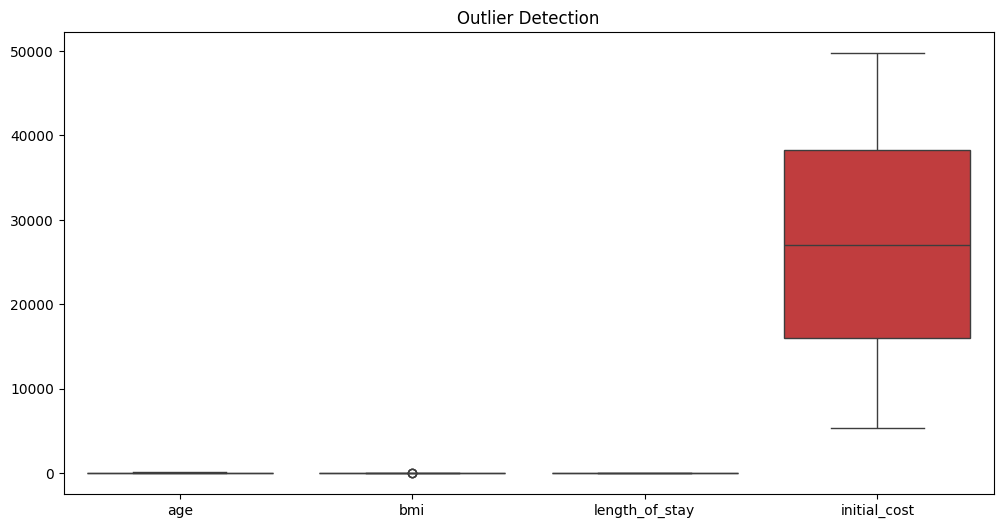

        Model        R2         RMSE          MAE
0      Linear  0.931491  2371.355341  1817.994205
1  Polynomial -0.063151  9341.566990  6418.275040
2       Ridge  0.917020  2609.818043  2095.229104
3       Lasso  0.931491  2371.352169  1818.013275
4  ElasticNet  0.919789  2565.903835  2054.256759


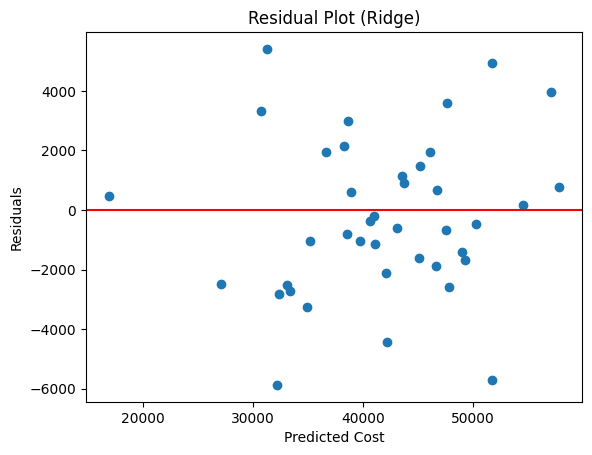

                Feature  Coefficient
5        severity_score  4543.323700
3        length_of_stay  4318.866346
4        num_procedures  2940.521626
2   previous_admissions  2258.394575
6          initial_cost  1728.556156
7           risk_factor  1382.471440
0                   age  1210.741060
10  insurance_type_None  -499.976282
12         region_North  -454.222427
8          cost_per_day  -365.687687
Predicted Readmission Cost: $ 36190.89831736713


In [18]:
##  Module 5: Capstone Project (Mastery Level)

###  Comprehensive Real-World Project

# **Scenario:** You're a data scientist at a healthcare analytics company. You need to predict hospital readmission costs based on patient data to help hospitals optimize resource allocation.

# **Dataset Description:**
# - Patient age, BMI, previous admissions
# - Length of hospital stay, number of procedures
# - Diagnosis severity score (1-10)
# - Insurance type, geographic region
# - Initial admission cost

# **Sample Dataset:**
# ```python
# Healthcare readmission cost data
np.random.seed(123)
n_patients = 200

healthcare_data = {
    'age': np.random.randint(18, 90, n_patients),
    'bmi': np.random.normal(28, 6, n_patients),
    'previous_admissions': np.random.randint(0, 8, n_patients),
    'length_of_stay': np.random.randint(1, 21, n_patients),
    'num_procedures': np.random.randint(0, 10, n_patients),
    'severity_score': np.random.randint(1, 11, n_patients),
    'insurance_type': np.random.choice(['Private', 'Medicare', 'Medicaid', 'None'], n_patients),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n_patients),
    'initial_cost': np.random.uniform(5000, 50000, n_patients)
}

df_healthcare = pd.DataFrame(healthcare_data)

# Create realistic target with complex relationships
df_healthcare['readmission_cost'] = (
    2000 +
    50 * df_healthcare['age'] +
    100 * df_healthcare['bmi'] +
    1500 * df_healthcare['previous_admissions'] +
    800 * df_healthcare['length_of_stay'] +
    1200 * df_healthcare['num_procedures'] +
    2000 * df_healthcare['severity_score'] +
    0.15 * df_healthcare['initial_cost'] +
    np.random.normal(0, 3000, n_patients)
)
# **Your Task (Full ML Pipeline):**

# 1. **Data Exploration & Preprocessing**
#    - Load and explore the data
#    - Handle missing values
#    - Detect and handle outliers
#    - Create new features (feature engineering)
#    - Encode categorical variables

print(df_healthcare.head())
print(df_healthcare.info())
print(df_healthcare.describe())

# Handling numerical missing values with median (robust to outliers)
df_healthcare['bmi'].fillna(df_healthcare['bmi'].median(), inplace=True)
df_healthcare['previous_admissions'].fillna(df_healthcare['previous_admissions'].median(), inplace=True)

# Detecting Outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df_healthcare[['age','bmi','length_of_stay','initial_cost']])
plt.title("Outlier Detection")
plt.show()

# New features
# risk score
df_healthcare['risk_factor'] = (
    df_healthcare['severity_score'] * df_healthcare['previous_admissions']
)
# cost per day
df_healthcare['cost_per_day'] = df_healthcare['initial_cost'] / df_healthcare['length_of_stay']

# Encoding Categorical Values
df_healthcare = pd.get_dummies(df_healthcare, columns=['insurance_type','region'], drop_first=True)

# 2. **Model Development**
#    - Build and compare multiple regression models:
#      * Simple linear regression (baseline)
#      * Multiple linear regression
#      * Polynomial regression (degree 2-3)
#      * Ridge regression
#      * Lasso regression
#      * Elastic Net

X = df_healthcare.drop('readmission_cost', axis=1)
y = df_healthcare['readmission_cost']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simple Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

# Multiple Linear Regression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

y_pred_poly = lr_poly.predict(X_test_poly)

# Ridge Regression
ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# Elastic Net
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)
y_pred_elastic = elastic.predict(X_test_scaled)

# 3. **Model Evaluation & Selection**
#    - Use cross-validation for all models
#    - Compare using multiple metrics (RÂ², RMSE, MAE)
#    - Perform residual analysis
#    - Check model assumptions

# Evaluation Function
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return [name, r2, rmse, mae]

results = []
results.append(evaluate_model("Linear", y_test, y_pred_lr))
results.append(evaluate_model("Polynomial", y_test, y_pred_poly))
results.append(evaluate_model("Ridge", y_test, y_pred_ridge))
results.append(evaluate_model("Lasso", y_test, y_pred_lasso))
results.append(evaluate_model("ElasticNet", y_test, y_pred_elastic))

results_df = pd.DataFrame(results, columns=["Model","R2","RMSE","MAE"])
print(results_df)

# Residual Analysis
residuals = y_test - y_pred_ridge
plt.scatter(y_pred_ridge, residuals)
plt.axhline(0,color='red')
plt.xlabel("Predicted Cost")
plt.ylabel("Residuals")
plt.title("Residual Plot (Ridge)")
plt.show()

# 4. **Business Insights**
#    - Interpret coefficients in business terms
# severity_score -> very expensive treatments
# previous_admissions -> chronic patients
# length_of_saty -> hospital resource use
# initial_cost -> complicated procedures

#    - Identify top cost drivers
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df.head(10))

#    - Make recommendations for cost reduction
# Reduce readmission via follow-up care
# Focus on chronic patients monitoring
# Early discharge planning
# Preventive outpatient programs

# 5. **Deployment Preparation**
#    - Create a prediction function
def predict_readmission_cost(patient_data):
    patient_df = pd.DataFrame([patient_data])
    patient_df = pd.get_dummies(patient_df)

    # align columns
    patient_df = patient_df.reindex(columns=X.columns, fill_value=0)

    patient_scaled = scaler.transform(patient_df)
    prediction = ridge.predict(patient_scaled)

    return prediction[0]

#    - Validate on new data
sample_patient = {
    'age': 65,
    'bmi': 31,
    'previous_admissions': 2,
    'length_of_stay': 7,
    'num_procedures': 3,
    'severity_score': 6,
    'initial_cost': 20000,
    'risk_factor': 12,
    'cost_per_day': 2857,
    'insurance_type_Medicare':1,
    'insurance_type_Medicaid':0,
    'insurance_type_None':0,
    'region_South':1,
    'region_East':0,
    'region_West':0
}

print("Predicted Readmission Cost: $", predict_readmission_cost(sample_patient))
#    - Document limitations and assumptions


# Add some missing values to make it realistic
df_healthcare.loc[np.random.choice(df_healthcare.index, 10), 'bmi'] = np.nan
df_healthcare.loc[np.random.choice(df_healthcare.index, 5), 'previous_admissions'] = np.nan
# ```

# **Deliverables:**
# 1. Jupyter notebook with complete analysis
# 2. Model comparison report
# 3. Business recommendations document
# 4. Prediction function ready for deployment

# **Evaluation Criteria:**
# - Data preprocessing quality (20%)
# - Model implementation correctness (25%)
# - Model evaluation thoroughness (20%)
# - Code quality and documentation (15%)
# - Business insights and recommendations (20%)

# **Why This Matters:**
# This capstone brings together everything you've learned. Real-world ML projects require the full pipelineâ€”from messy data to actionable business recommendations. Completing this demonstrates your readiness for professional data science work.

# ---


### Key Concepts to Learn
# - **Bias-Variance Tradeoff:** Balance between model simplicity and complexity
# - **Cross-Validation:** Robust method for model evaluation
# - **Feature Engineering:** Creating new features from existing data
# - **Regularization:** Techniques to prevent overfitting
# - **Model Interpretability:** Understanding and explaining model predictions
